<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/5_Extracci%C3%B3n_de_Caracter%C3%ADsticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [115]:
df_piso = pd.read_csv("Analisis GAC Full7agosto 2026(Bitacora de Piso).csv")

In [116]:
df_piso.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


In [117]:
print(df_piso.isnull().sum())

Fecha                                          36
Nombre Cliente                                 37
Telefono                                      234
Asesor                                         38
Esatus Lead                                    37
PDM                                             0
SDC                                            18
Estatus de SDC                                232
Venta                                          18
Temperatura                                   224
Inter Gerente                                  18
¿Por que no hubo prueba de manejo?            218
¿Por que no hubo Solicitud de credito?        220
¿Por que no hubo intervencion del Gerente?    223
¿Por que no hubo proceso wow?                 222
¿Por que no se ha formalizado la compra?      223
5 porques clientes de piso                    226
Comentarios                                   212
Unnamed: 18                                   234
Unnamed: 19                                   234


**Limpieza de datos**

In [118]:
# 1. Copia para trabajar
df_limpio = df_piso.copy()

In [119]:
# Elimina espacios al inicio y al final de todos los nombres de columnas
df_limpio.columns = df_limpio.columns.str.strip()

In [120]:
df_limpio = df_limpio.dropna(subset=["Nombre Cliente"])

In [121]:
df_limpio.isnull().sum()

Fecha                                           0
Nombre Cliente                                  0
Telefono                                      197
Asesor                                          1
Esatus Lead                                     0
PDM                                             0
SDC                                             0
Estatus de SDC                                195
Venta                                           0
Temperatura                                   187
Inter Gerente                                   0
¿Por que no hubo prueba de manejo?            181
¿Por que no hubo Solicitud de credito?        183
¿Por que no hubo intervencion del Gerente?    186
¿Por que no hubo proceso wow?                 185
¿Por que no se ha formalizado la compra?      186
5 porques clientes de piso                    189
Comentarios                                   175
Unnamed: 18                                   197
Unnamed: 19                                   197


In [122]:
columnas_sin_info = ['Telefono',  'Asesor', 'Estatus de SDC', 'Temperatura',
'¿Por que no hubo prueba de manejo?', '¿Por que no hubo Solicitud de credito?',
'¿Por que no hubo intervencion del Gerente?', '¿Por que no hubo proceso wow?',
'¿Por que no se ha formalizado la compra?', '5 porques clientes de piso',
'Comentarios'
]

df_limpio[columnas_sin_info] = df_limpio[columnas_sin_info].fillna('Sin información')

In [123]:
df_limpio.isnull().sum()

Fecha                                           0
Nombre Cliente                                  0
Telefono                                        0
Asesor                                          0
Esatus Lead                                     0
PDM                                             0
SDC                                             0
Estatus de SDC                                  0
Venta                                           0
Temperatura                                     0
Inter Gerente                                   0
¿Por que no hubo prueba de manejo?              0
¿Por que no hubo Solicitud de credito?          0
¿Por que no hubo intervencion del Gerente?      0
¿Por que no hubo proceso wow?                   0
¿Por que no se ha formalizado la compra?        0
5 porques clientes de piso                      0
Comentarios                                     0
Unnamed: 18                                   197
Unnamed: 19                                   197


In [124]:
columnas_unnamed = df_limpio.filter(like='Unnamed').columns

df_limpio = df_limpio.drop(columns=columnas_unnamed)

In [125]:
df_limpio.isnull().sum()

Fecha                                         0
Nombre Cliente                                0
Telefono                                      0
Asesor                                        0
Esatus Lead                                   0
PDM                                           0
SDC                                           0
Estatus de SDC                                0
Venta                                         0
Temperatura                                   0
Inter Gerente                                 0
¿Por que no hubo prueba de manejo?            0
¿Por que no hubo Solicitud de credito?        0
¿Por que no hubo intervencion del Gerente?    0
¿Por que no hubo proceso wow?                 0
¿Por que no se ha formalizado la compra?      0
5 porques clientes de piso                    0
Comentarios                                   0
dtype: int64

**Estandarización de variables categóricas**

In [126]:
df_limpio['Asesor'] = df_limpio['Asesor'].str.title().str.strip()
df_limpio['Asesor'] = df_limpio['Asesor'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

In [127]:
# Columnas a usar
var_categoricas = ['Asesor', 'Esatus Lead', 'PDM', 'SDC', 'Estatus de SDC', 'Venta', 'Inter Gerente',
'Temperatura', '¿Por que no hubo prueba de manejo?', '¿Por que no hubo Solicitud de credito?']

# 3. Limpiar los textos (mayúsculas, acentos y espacios al inicio/final)
for col in var_categoricas:
    if col in df_limpio.columns and df_limpio[col].dtype == 'object':

# Arregla mayúsculas
        df_limpio[col] = df_limpio[col].astype(str).str.title().str.strip()
        
# Quita acentos para que no duplique registros
        df_limpio[col] = (df_limpio[col]
                          .str.normalize('NFKD')
                          .str.encode('ascii', errors='ignore')
                          .str.decode('utf-8'))

**Outliers**

La base de Bitacora de Piso está compuesta únicamente por variables cualitativas / categóricas.  No hay métricas de distancia numérica por lo que no se puede calcular una desviación estándar para identificar outliers

**2da parte Variables Categoricas**

In [128]:
var_categoricas = ['Asesor', 'Esatus Lead', 'PDM', 'SDC','Estatus de SDC', 'Venta', 'Inter Gerente',
'Temperatura', '¿Por que no hubo prueba de manejo?','¿Por que no hubo Solicitud de credito?']

In [129]:
# 1. Análisis univariado
Tabla_freq = df_limpio['Asesor'].value_counts().reset_index()
Tabla_freq

,Asesor,count
0,Aurelio,35
1,Mauricio,28
2,Pedro,25
3,Victor,20
4,Alan,14
5,Aurelio Torres,13
6,Pedro Gonzalez,12
7,Alan Gonzalez,11
8,Ricardo,10
9,Mauricio Vazquez,7


In [130]:
#Conservar los registros que aparecen más de una vez
Filtro = Tabla_freq[Tabla_freq['count'] > 1]
Filtro

,Asesor,count
0,Aurelio,35
1,Mauricio,28
2,Pedro,25
3,Victor,20
4,Alan,14
5,Aurelio Torres,13
6,Pedro Gonzalez,12
7,Alan Gonzalez,11
8,Ricardo,10
9,Mauricio Vazquez,7


In [131]:
# Ajustar indice
Filtro_index = Filtro.set_index('Asesor')
Filtro_index

,count
Asesor,
Aurelio,35
Mauricio,28
Pedro,25
Victor,20
Alan,14
Aurelio Torres,13
Pedro Gonzalez,12
Alan Gonzalez,11
Ricardo,10


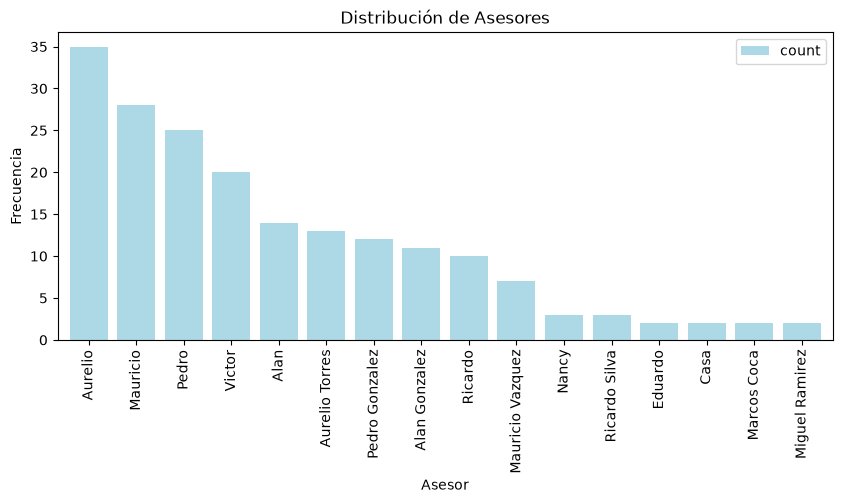

In [132]:
#Grafica 
Filtro_index.plot( kind='bar', width=0.8,figsize=(10,4), color = "lightblue")
plt.title('Distribución de Asesores')
plt.xlabel('Asesor')
plt.ylabel('Frecuencia')

plt.show()

In [133]:
# 2. Análisis univariado 

df_limpio['Esatus Lead'] = df_limpio['Esatus Lead'].astype(str).str.strip().str.capitalize()
Tabla_freq2 = df_limpio['Esatus Lead'].value_counts().reset_index()
Tabla_freq2

,Esatus Lead,count
0,Activo,168
1,Cerrado,18
2,Venta,7
3,Finalizado,4


In [134]:
# Ajustar índice 
Filtro_index2 = Tabla_freq2.set_index('Esatus Lead')
Filtro_index2

,count
Esatus Lead,
Activo,168
Cerrado,18
Venta,7
Finalizado,4


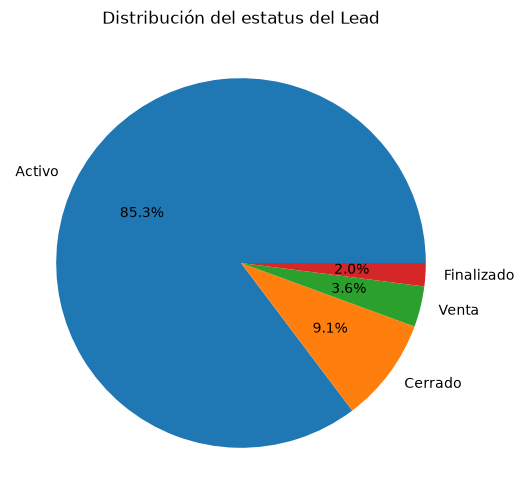

In [135]:
# Grafico
df_limpio['Esatus Lead'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))

plt.title('Distribución del estatus del Lead')
plt.ylabel('') 
plt.show()

In [136]:
# 3. Análisis univariado PDM
Tabla_freq3 = df_limpio['PDM'].value_counts().reset_index()
Tabla_freq3

,PDM,count
0,False,122
1,True,75


In [137]:
# Ajustar índice
Filtro_index3 = Tabla_freq3.set_index('PDM')
Filtro_index3

,count
PDM,
False,122
True,75


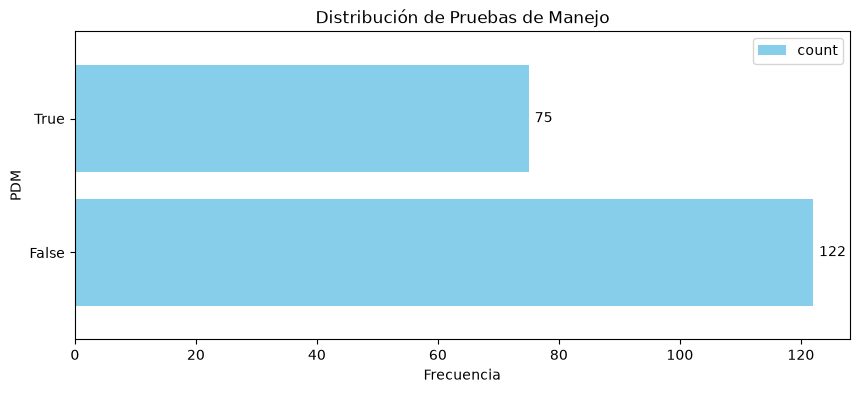

In [ ]:
# Grafica 3

Filtro_index3.plot( kind='barh', width=0.8, figsize=(10,4), color = 'skyblue')

plt.title('Distribución de Pruebas de Manejo')
plt.xlabel('Frecuencia')
plt.ylabel('PDM')

for i, valor in enumerate(Filtro_index3['count']):
    plt.text(valor + 1, i, str(valor), va='center')

plt.show()

In [139]:
# 4 Análisis univariado
Tabla_freq4 = df_limpio['SDC'].value_counts().reset_index()

Tabla_freq4

,SDC,count
0,False,193
1,True,4


In [140]:
# Ajustar índice
Filtro_index4 = Tabla_freq4.set_index('SDC')
Filtro_index4

,count
SDC,
False,193
True,4


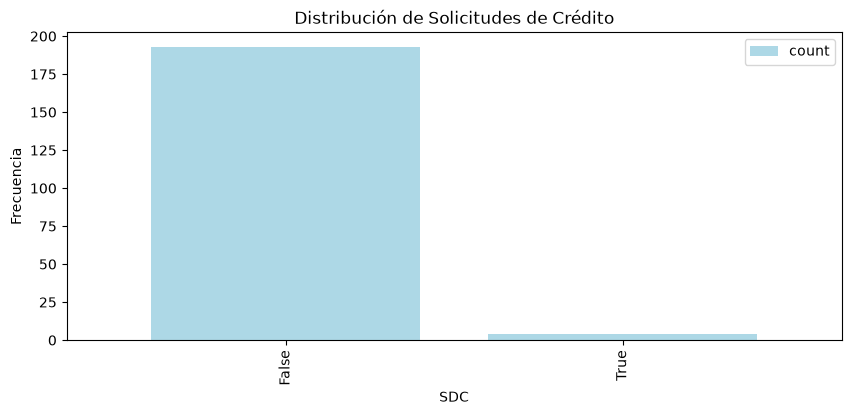

In [141]:
# Grafica
Filtro_index4.plot( kind='bar', width=0.8, figsize=(10,4), color = "lightblue")

plt.title('Distribución de Solicitudes de Crédito')
plt.xlabel('SDC')
plt.ylabel('Frecuencia')

plt.show()

In [142]:
# 5
Tabla_freq5 = df_limpio['Estatus de SDC'].value_counts().reset_index()

Tabla_freq5

,Estatus de SDC,count
0,Sin información,195
1,Analisis,1
2,Rechazada,1


In [143]:
# Ajustar índice

Filtro_index5 = Tabla_freq5.set_index('Estatus de SDC')

Filtro_index5

,count
Estatus de SDC,
Sin información,195
Analisis,1
Rechazada,1


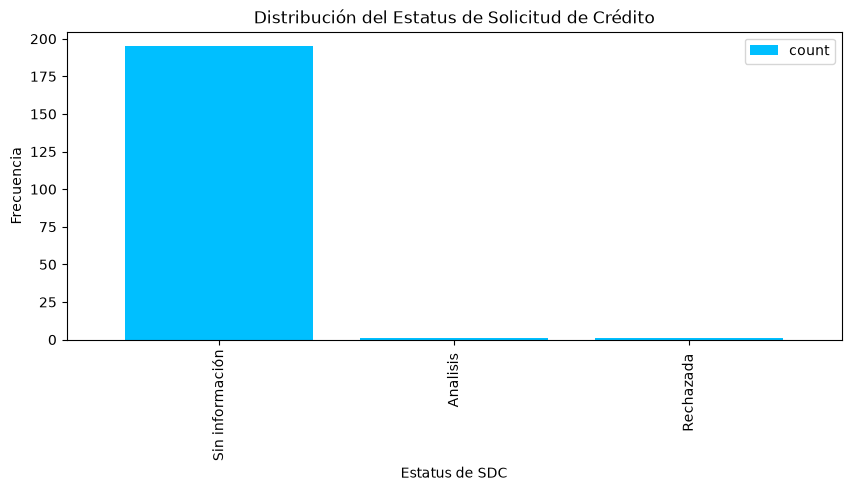

In [144]:
# Gráfico de barras

Filtro_index5.plot( kind='bar', width=0.8, figsize=(10,4), color= "deepskyblue")

plt.title('Distribución del Estatus de Solicitud de Crédito')
plt.xlabel('Estatus de SDC')
plt.ylabel('Frecuencia')

plt.show()

In [145]:
# 6
Tabla_freq6 = df_limpio['Venta'].value_counts().reset_index()

Tabla_freq6

,Venta,count
0,False,193
1,True,4


In [146]:
# Ajustaríndice
Filtro_index6 = Tabla_freq6.set_index('Venta')

Filtro_index6

,count
Venta,
False,193
True,4


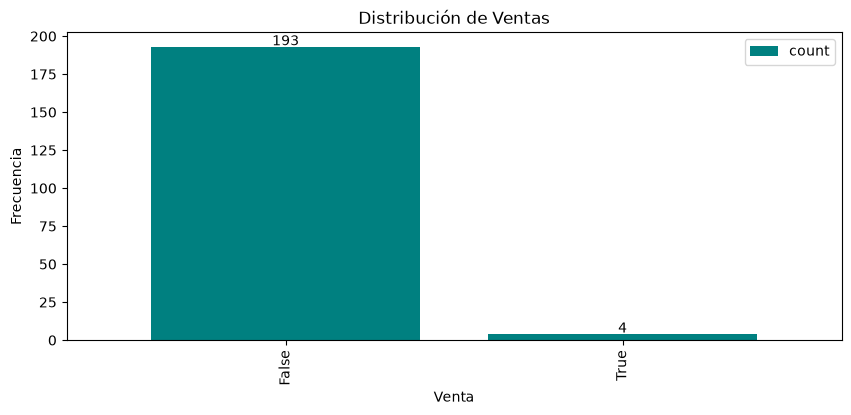

In [ ]:
# Gráfico 
Filtro_index6.plot(kind='bar', width=0.8, figsize=(10,4), color= "teal")

plt.title('Distribución de Ventas')
plt.xlabel('Venta')
plt.ylabel('Frecuencia')

for i, valor in enumerate(Filtro_index6['count']):
    plt.text(i, valor + 1, str(valor), ha='center')

plt.show()

In [148]:
# 7
Tabla_freq7 = df_limpio['Temperatura'].value_counts().reset_index()

Tabla_freq7

,Temperatura,count
0,Sin información,187
1,Lead InteresBajo,4
2,Lead Interes Alto,3
3,Lead Interes Medio,1
4,Ebullición,1
5,Tibio,1


In [149]:
# Ajustaríndice
Filtro_index7 = Tabla_freq7.set_index('Temperatura')
Filtro_index7

,count
Temperatura,
Sin información,187
Lead InteresBajo,4
Lead Interes Alto,3
Lead Interes Medio,1
Ebullición,1
Tibio,1


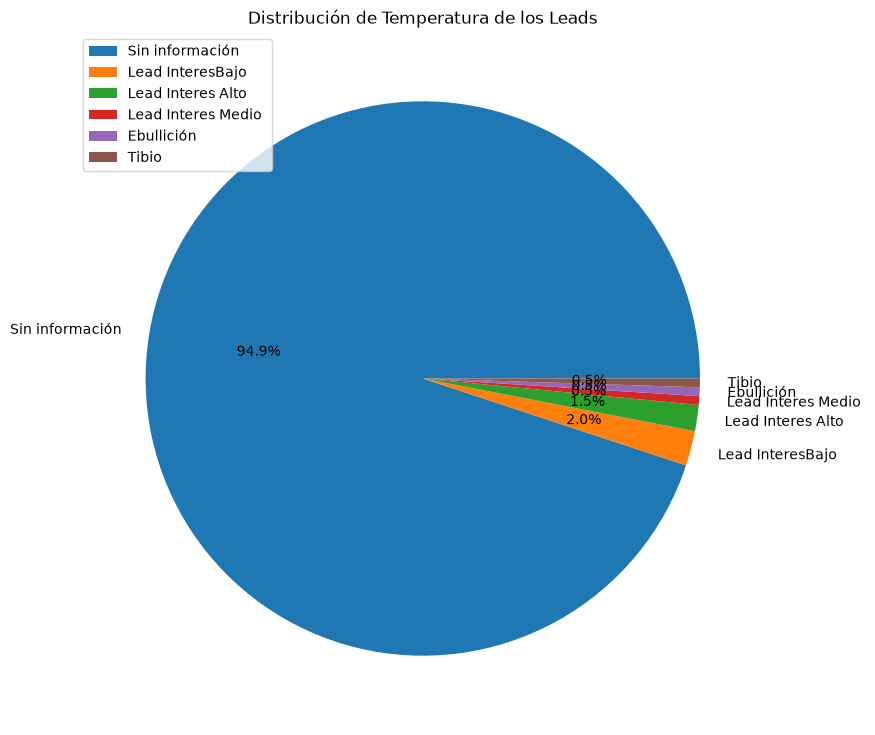

In [197]:
# Grafico

Filtro_index7.plot(kind='pie', y='count', autopct='%1.1f%%', figsize=(10,9))
plt.title('Distribución de Temperatura de los Leads')
plt.ylabel('')

plt.show()

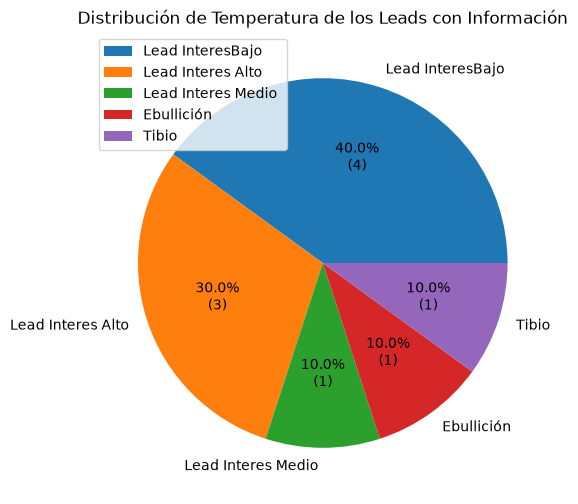

In [201]:
# Quito "Sin información" solamente para q se vea mejor la gráfica

Grafica_temp = Filtro_index7.drop('Sin información')

Grafica_temp.plot( kind='pie', y='count', autopct=lambda p: f'{p:.1f}%\n({p*Grafica_temp["count"].sum()/100:.0f})',
figsize=(7,6))

plt.title('Distribución de Temperatura de los Leads con Información')
plt.ylabel('')

plt.show()

In [152]:
# 8 Análisis univariado
Tabla_freq8 = df_limpio['Inter Gerente'].value_counts().reset_index()
Tabla_freq8

,Inter Gerente,count
0,False,166
1,True,31


In [153]:
# Ajustar índice
Filtro_index8 = Tabla_freq8.set_index('Inter Gerente')
Filtro_index8

,count
Inter Gerente,
False,166
True,31


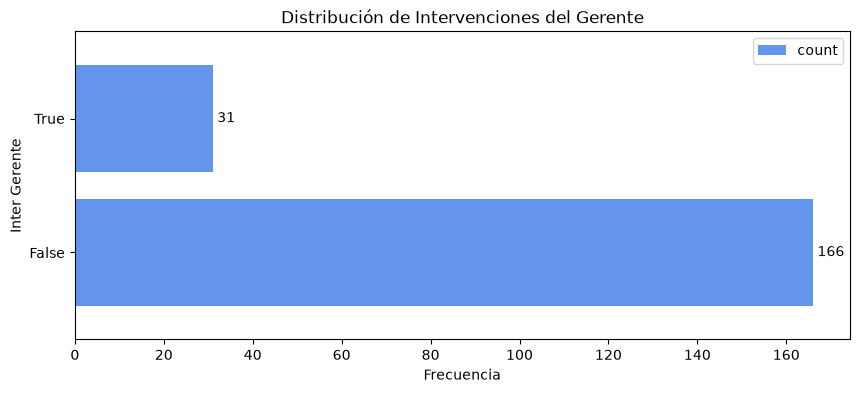

In [203]:
# Gráfico de barras

Filtro_index8.plot(kind='barh', width=0.8, figsize=(10,4), color = "cornflowerblue")
plt.title('Distribución de Intervenciones del Gerente')
plt.xlabel('Frecuencia')
plt.ylabel('Inter Gerente')

#mostrar valores

for i, valor in enumerate(Filtro_index8['count']):
    plt.text(valor + 1, i, str(valor), va='center')

plt.show()

In [155]:
# 9 un análisis univariado
Tabla_freq9 = df_limpio['¿Por que no hubo prueba de manejo?'].value_counts().reset_index()
Tabla_freq9


,¿Por que no hubo prueba de manejo?,count
0,Sin información,181
1,Sí hubo prueba de manejo.,1
2,La clienta piensa acudir con sus hijos para ha...,1
3,"Sí hubo prueba de manejo por la tarde, ya que ...",1
4,El cliente no quiso porque sabe que no se encu...,1
5,"Sí hubo prueba de manejo, el cliente quedo fas...",1
6,El cliente ya había realizado una prueba de ma...,1
7,Sí realizo prueba de manejo y se fue muy satis...,1
8,Porque el cliente va a comprar sin ver el vehí...,1
9,"Sí hubo ya dos pruebas de manejo, en la primer...",1


In [156]:
# Ajustar índice
Filtro_index9 = Tabla_freq9.set_index('¿Por que no hubo prueba de manejo?')
Filtro_index9

,count
¿Por que no hubo prueba de manejo?,
Sin información,181
Sí hubo prueba de manejo.,1
La clienta piensa acudir con sus hijos para hacer la prueba de manejo. Solo se encuentra valorando que vehículo le gusta más. Se le proporcionan fichas y material impreso.,1
"Sí hubo prueba de manejo por la tarde, ya que el cliente fue por sus hijas a la escuela y regreso. La prueba de manejo le encanto y se convenció.",1
"El cliente no quiso porque sabe que no se encuentra en condiciones para realizar la compra, a pesar de que se le insitió comenta que esta muy satisfecho con la atención",1
"Sí hubo prueba de manejo, el cliente quedo fascinado.",1
"El cliente ya había realizado una prueba de manejo en el mes de noviembre, con nuestra Asesor de Ventas Lupita.",1
Sí realizo prueba de manejo y se fue muy satisfecho. Sin embargo el venía buscando el sedan empow.,1
"Porque el cliente va a comprar sin ver el vehículo, es de Verecruz.",1


**Tratamiento de preguntas abiertas**

Debido a que las respuestas de las preguntas abiertas tienen una respuesta diferente, decidi agrupar por categorías según motivos similares. Esto permite resumir la información, identificar patrones y representarla de forma más clara mediante tablas y gráficas

In [157]:
df_limpio['Motivo_PDM'] = 'Otra razón'

In [158]:
df_limpio.loc[ df_limpio['¿Por que no hubo prueba de manejo?'] == 'Sin información', 'Motivo_PDM'] = 'Sin información'

In [159]:
df_limpio.loc[ df_limpio['¿Por que no hubo prueba de manejo?'].str.contains('sí hubo|sí realiz|prueba de manejo por la tarde|ya había realizado',
case=False, na=False), 'Motivo_PDM'] = 'Sí realizó prueba'

In [160]:
df_limpio.loc[df_limpio['¿Por que no hubo prueba de manejo?'].str.contains('tiempo|ocupado', case=False, na=False), 
'Motivo_PDM'] = 'Falta de tiempo/disponibilidad'

In [161]:
df_limpio.loc[df_limpio['¿Por que no hubo prueba de manejo?'].str.contains('no desea|no quiso', case=False, na=False),
'Motivo_PDM'] = 'Cliente no desea'

In [162]:
df_limpio.loc[df_limpio['¿Por que no hubo prueba de manejo?'].str.contains('sábado|piensa acudir|esposa|pareja',
case=False, na=False), 'Motivo_PDM'] = 'Prueba pendiente'

In [163]:
df_limpio.loc[df_limpio['¿Por que no hubo prueba de manejo?'].str.contains('no habia unidad|no había unidad',
case=False, na=False), 'Motivo_PDM'] = 'Falta de unidad'

In [164]:
# Obtengo Análisis univariado
Tabla_freq9 = df_limpio['Motivo_PDM'].value_counts().reset_index()
Tabla_freq9

,Motivo_PDM,count
0,Sin información,181
1,Sí realizó prueba,5
2,Prueba pendiente,4
3,Cliente no desea,2
4,Otra razón,2
5,Falta de tiempo/disponibilidad,2
6,Falta de unidad,1


In [165]:
Filtro_index9 = Tabla_freq9.set_index('Motivo_PDM')
Filtro_index9

,count
Motivo_PDM,
Sin información,181
Sí realizó prueba,5
Prueba pendiente,4
Cliente no desea,2
Otra razón,2
Falta de tiempo/disponibilidad,2
Falta de unidad,1


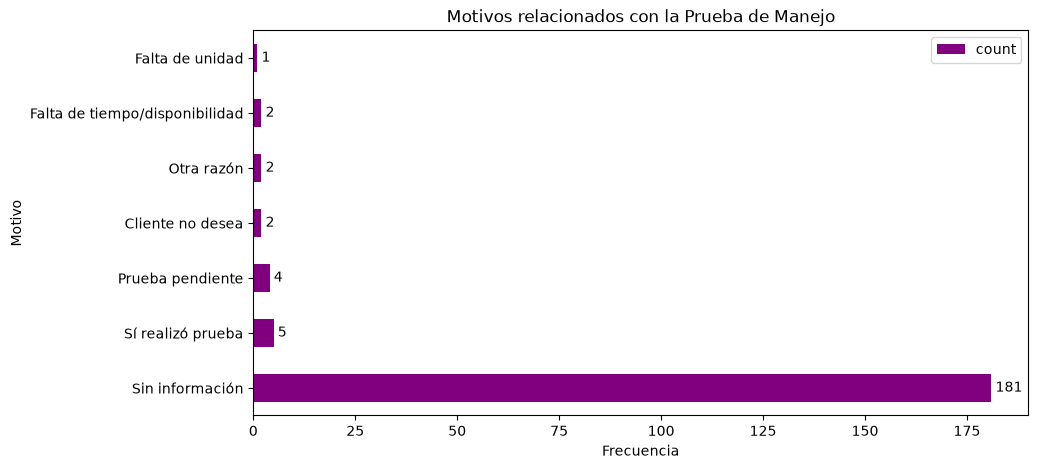

In [215]:
Filtro_index9.plot(kind='barh', figsize=(10,5), color = 'purple')
plt.title('Motivos relacionados con la Prueba de Manejo')
plt.xlabel('Frecuencia')
plt.ylabel('Motivo')

for i, valor in enumerate(Filtro_index9['count']):
    plt.text(valor + 1, i, str(valor), va='center')

plt.show()


In [167]:
# 10 análisis univariado
Tabla_freq10 = df_limpio['¿Por que no hubo Solicitud de credito?'].value_counts().reset_index()
Tabla_freq10

,¿Por que no hubo Solicitud de credito?,count
0,Sin información,183
1,"El cliente acudió con una prima, para ella ser...",1
2,Es una decisión que prefiere tomar con sus hijos.,1
3,Ingresa SDC con el perfil de ella y el de su e...,1
4,El cliente comenta que en este momento tiene c...,1
5,"Sí hubo SDC, el cliente trabaja en Santander y...",1
6,El cliente comenta que compraría a través de u...,1
7,"Prefiere autos sedanes e insistió en esperar, ...",1
8,Es compra de contado.,1
9,Es venta de contado,1


In [168]:
# Ajustar índice
Filtro_index10 = Tabla_freq10.set_index('¿Por que no hubo Solicitud de credito?')
Filtro_index10

,count
¿Por que no hubo Solicitud de credito?,
Sin información,183
"El cliente acudió con una prima, para ella sería el vehículo pero comenta que no será pronto, solo se encontraba considerando opciones para que pueda saber cuánto cuestan los vehículos.",1
Es una decisión que prefiere tomar con sus hijos.,1
Ingresa SDC con el perfil de ella y el de su esposo.,1
"El cliente comenta que en este momento tiene compromisos economicos que el impiden cumplir con la capacidad de pago, acaba de dar de alta una empresa con la que en unos meses podrá tener historial ya que en sus cuentas dejo de tener moviemientos desde noviembre por inversiones que hizo en obras.",1
"Sí hubo SDC, el cliente trabaja en Santander y tiene beneficios especiales.",1
"El cliente comenta que compraría a través de una cooperativa y debe de primero revisar el proceso, por el momento se encontraba valorando opciones.",1
"Prefiere autos sedanes e insistió en esperar, así el auto tarde 1 año en llegar.",1
Es compra de contado.,1


**Categorización de la pregunta: ¿Por qué no hubo Solicitud de crédito?**

In [169]:
df_limpio['Motivo_SDC'] = 'Otra razón'

In [170]:
df_limpio.loc[df_limpio['¿Por que no hubo Solicitud de credito?'] == 'Sin información', 'Motivo_SDC'] = 'Sin información'

In [171]:
df_limpio.loc[df_limpio['¿Por que no hubo Solicitud de credito?'].str.contains('ingresa SDC|sí hubo SDC',
case=False, na=False), 'Motivo_SDC'] = 'Sí realizó SDC'

In [172]:
df_limpio.loc[df_limpio['¿Por que no hubo Solicitud de credito?'].str.contains('contado',
case=False, na=False),'Motivo_SDC'] = 'Compra de contado'

In [173]:
df_limpio.loc[df_limpio['¿Por que no hubo Solicitud de credito?'].str.contains('hijos|valorando opciones|esperar',case=False, na=False),
'Motivo_SDC'] = 'Decisión pendiente'

In [174]:
df_limpio.loc[df_limpio['¿Por que no hubo Solicitud de credito?'].str.contains('compromisos economicos|capacidad de pago|historial',
case=False, na=False), 'Motivo_SDC'] = 'Situación económica'

In [175]:
df_limpio.loc[df_limpio['¿Por que no hubo Solicitud de credito?'].str.contains('cooperativa|través de su mamá',
case=False, na=False),'Motivo_SDC'] = 'Crédito por otro medio/persona'

In [176]:
df_limpio.loc[df_limpio['¿Por que no hubo Solicitud de credito?'].str.contains('no quiere tramitar', case=False, na=False),
'Motivo_SDC'] = 'No desea tramitar crédito'

In [177]:
df_limpio.loc[df_limpio['¿Por que no hubo Solicitud de credito?'].str.contains('despues de que maneje|después de que maneje',
case=False, na=False), 'Motivo_SDC'] = 'Pendiente de otro proceso'

In [178]:
# 10 análisis univariado

Tabla_freq10 = df_limpio['Motivo_SDC'].value_counts().reset_index()
Tabla_freq10

,Motivo_SDC,count
0,Sin información,183
1,Compra de contado,4
2,Decisión pendiente,2
3,Sí realizó SDC,2
4,Crédito por otro medio/persona,2
5,Otra razón,1
6,Situación económica,1
7,Pendiente de otro proceso,1
8,No desea tramitar crédito,1


In [179]:
Filtro_index10 = Tabla_freq10.set_index('Motivo_SDC')
Filtro_index10

,count
Motivo_SDC,
Sin información,183
Compra de contado,4
Decisión pendiente,2
Sí realizó SDC,2
Crédito por otro medio/persona,2
Otra razón,1
Situación económica,1
Pendiente de otro proceso,1
No desea tramitar crédito,1


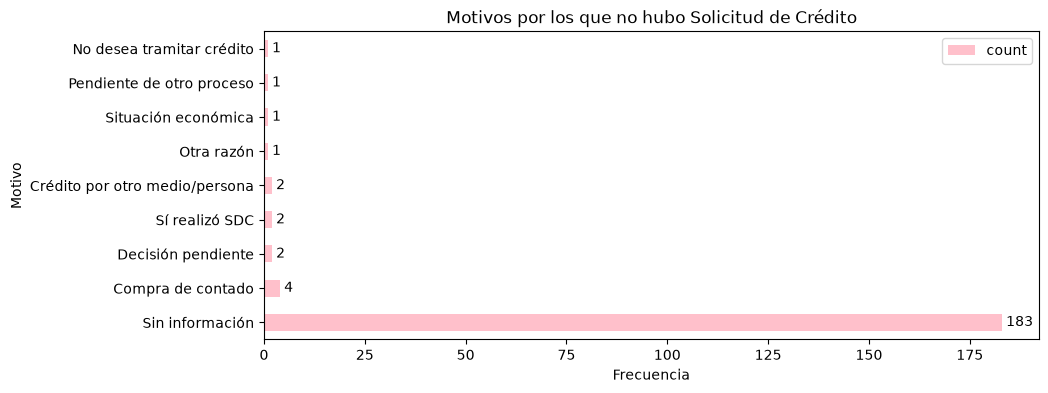

In [ ]:
# 
Filtro_index10.plot(kind='barh', figsize=(10,4), alpha = 1, color = "pink")

plt.title('Motivos por los que no hubo Solicitud de Crédito')
plt.xlabel('Frecuencia')
plt.ylabel('Motivo')

for i, valor in enumerate(Filtro_index10['count']):
    plt.text(valor + 1, i, str(valor), va='center')

plt.show()

In [181]:
# Verifico dimensiones
print(df_limpio.shape)

# Verifico valores nulos
print(df_limpio.isnull().sum())

# Visualizo los primeros registros
df_limpio.head()

(197, 20)
Fecha                                         0
Nombre Cliente                                0
Telefono                                      0
Asesor                                        0
Esatus Lead                                   0
PDM                                           0
SDC                                           0
Estatus de SDC                                0
Venta                                         0
Temperatura                                   0
Inter Gerente                                 0
¿Por que no hubo prueba de manejo?            0
¿Por que no hubo Solicitud de credito?        0
¿Por que no hubo intervencion del Gerente?    0
¿Por que no hubo proceso wow?                 0
¿Por que no se ha formalizado la compra?      0
5 porques clientes de piso                    0
Comentarios                                   0
Motivo_PDM                                    0
Motivo_SDC                                    0
dtype: int64


,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,Inter Gerente,¿Por que no hubo prueba de manejo?,¿Por que no hubo Solicitud de credito?,¿Por que no hubo intervencion del Gerente?,¿Por que no hubo proceso wow?,¿Por que no se ha formalizado la compra?,5 porques clientes de piso,Comentarios,Motivo_PDM,Motivo_SDC
0,04/01/2025,Ubaldo Cruz Hernandez,Sin información,Aurelio,Activo,True,False,Sin información,False,Lead InteresBajo,True,Sí hubo prueba de manejo.,"El cliente acudió con una prima, para ella ser...","Sí hubo interacción del gerente, los cliente s...","Sí hubo proceso wow, se recibío al cliente con...",Tiempo de compra hasta el próximo año.,El cliente llego ocasionalmente antes de llega...,Sin información,Sí realizó prueba,Otra razón
1,04/01/2025,Olivia Cabello,Sin información,Pedro,Activo,False,False,Sin información,False,Lead InteresBajo,True,La clienta piensa acudir con sus hijos para ha...,Es una decisión que prefiere tomar con sus hijos.,Sí hubo intervención del Gerente. Converse con...,"Sí hubo un proceso wow, además de la interacci...",Sin información,Clienta viene buscando opciones para ella y su...,Sin información,Prueba pendiente,Decisión pendiente
2,04/02/2025,Ana Laura Espinoza,Sin información,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,True,"Sí hubo prueba de manejo por la tarde, ya que ...",Ingresa SDC con el perfil de ella y el de su e...,Sí hubo intervención del gerente en las dos vi...,Calificación 5,No se formalizo la venta ya que fue rechazado ...,El cliente visito la agencia porque iba pasand...,Sin información,Sí realizó prueba,Sí realizó SDC
3,04/02/2025,Elvis Sanchez,Sin información,Aurelio,Activo,False,False,Sin información,False,Lead InteresBajo,True,El cliente no quiso porque sabe que no se encu...,El cliente comenta que en este momento tiene c...,"Sí hubo intervención y me comento su estatus, ...",Calificación 5,Porque por el momento no cuenta con moviemient...,El Señor Elvis se encuentra evaluando diferent...,Sin información,Cliente no desea,Situación económica
4,04/03/2025,Ariel Fernando López,Sin información,Alan,Activo,True,False,Sin información,False,Sin información,True,Sin información,Sin información,Sin información,Sin información,Sin información,El cliente se encuentra en busqueda de renovar...,Sin información,Sin información,Sin información


In [182]:
# Guardar la base
df_limpio.to_csv('Bitacora de Piso_limpia.csv', index=False)